# Cross-sectional momentum — walkthrough

A step-by-step run of the 12-1 momentum strategy using the `quantbt` package: signal, dollar-neutral weights, an after-cost walk-forward backtest, a cost-sensitivity sweep, and capacity. Mirrors `scripts/run_momentum.py`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')  # run from the repo root either way

import pandas as pd
import matplotlib.pyplot as plt

from quantbt import metrics, plotting
from quantbt.backtest import daily_returns, simulate
from quantbt.costs import CostModel
from quantbt.data import load_dollar_adv
from quantbt.strategies.momentum import (
    momentum_signal, momentum_weights, month_end_rebalances,
)

## 1. Load prices
We read the committed universe CSV — 90 liquid US large-caps, 2015–2024. (Fixed present-day names, so there is some survivorship bias; disclosed, not corrected.)

In [2]:
prices = pd.read_csv('data/momentum_universe.csv', index_col=0, parse_dates=True)
print(prices.shape)
prices.tail(3).iloc[:, :6]

(2515, 90)


,AAPL,ABT,ACN,ADBE,ADI,AMAT
Date,,,,,,
2024-12-26,257.375580,111.854546,352.368317,450.160004,213.268448,165.477066
2024-12-27,253.967377,111.582840,348.213348,446.480011,212.221985,164.765976
2024-12-30,250.598907,109.457741,344.605896,445.799988,207.889313,161.615448


## 2. The 12-1 signal
Trailing 12-month return skipping the most recent month (the skip avoids short-term reversal). It only uses past prices, so there is no look-ahead.

In [3]:
signal = momentum_signal(prices)
signal.dropna().tail(3).iloc[:, :6]

,AAPL,ABT,ACN,ADBE,ADI,AMAT
Date,,,,,,
2024-12-26,0.212177,0.103062,0.038672,-0.132936,0.138503,0.070812
2024-12-27,0.222944,0.095856,0.042955,-0.118742,0.112750,0.062983
2024-12-30,0.219552,0.098947,0.046622,-0.137426,0.098296,0.058471


## 3. Dollar-neutral weights
Each month-end, long the top decile / short the bottom decile, equal-weighted within each leg. Long leg sums to +0.5 and short to -0.5 (net 0, gross 1).

In [4]:
rebalances = month_end_rebalances(prices.index)
weights = momentum_weights(prices, rebalances, quantile=0.1)
row = weights.iloc[-1]
print('net exposure:', round(row.sum(), 6), '| gross:', round(row.abs().sum(), 3))

net exposure: 0.0 | gross: 1.0


## 4. Backtest after costs
Positions are held from the day *after* each rebalance, and costs are charged on traded notional.

In [5]:
returns = daily_returns(prices)
result = simulate(returns, weights, CostModel())
pd.Series(result.summary()).round(3)

ann_return      0.005
ann_vol         0.129
sharpe          0.103
sortino         0.137
max_drawdown   -0.333
hit_rate        0.470
turnover        0.271
total_cost      0.021
dtype: float64

## 5. Cost-sensitivity sweep
Most of the (already thin) edge erodes as costs rise.

In [6]:
base = CostModel()
sweep = {f'{f:g}x': simulate(returns, weights, base.scaled(f)).summary()
         for f in (0.0, 1.0, 2.0, 3.0)}
pd.DataFrame(sweep).T[['ann_return', 'sharpe', 'max_drawdown']].round(3)

,ann_return,sharpe,max_drawdown
0x,0.007,0.119,-0.329
1x,0.005,0.103,-0.333
2x,0.003,0.087,-0.337
3x,0.001,0.071,-0.340


## 6. Capacity
AUM at which trades would hit 1% of a name's average dollar volume — bound by the least-liquid name in the universe.

In [7]:
adv = load_dollar_adv([], '2015-01-01', '2024-12-31', 'data/momentum_dollar_adv.csv')
cap = metrics.capacity(weights, adv, participation=0.01)
print(f'Capacity at 1% ADV: ${cap/1e6:,.0f}M')

Capacity at 1% ADV: $34M


## 7. Tearsheet

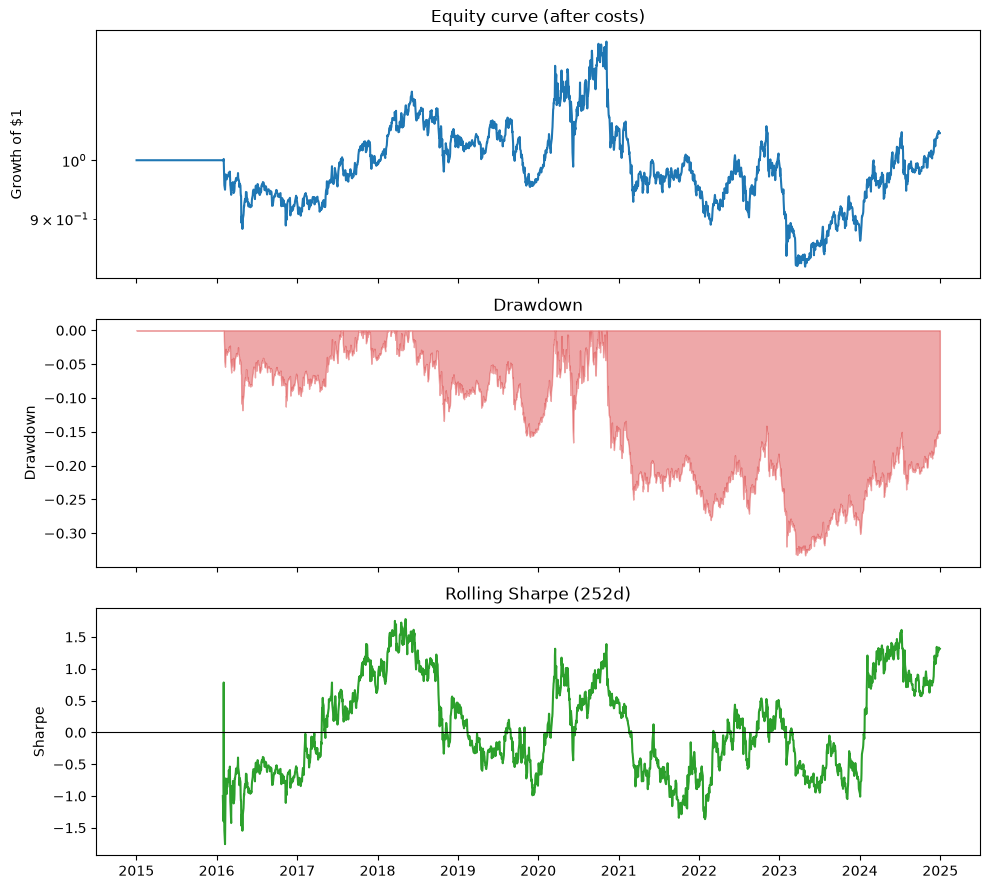

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plotting.plot_equity(result.equity, ax=axes[0])
plotting.plot_drawdown(result.equity, ax=axes[1])
plotting.plot_rolling_sharpe(result.returns, ax=axes[2])
fig.tight_layout()

## Takeaway
The edge is thin even gross (Sharpe ~0.12) and barely survives costs. Around 90 mega-caps that mostly rose together offer little cross-sectional dispersion, and 2015–2024 was a weak stretch for momentum. The honest read: naive large-cap momentum did not pay after costs this decade.